# Video 17a2: Exploratory Data Analysis - Distribution of pIC50 Values
Explanation Script:
"The pIC50 value is our regression target. Understanding its distribution helps us know if the data is skewed, if there are outliers, and what range of values we're working with. This influences how we interpret model performance."

pIC50 DISTRIBUTION ANALYSIS

1. DESCRIPTIVE STATISTICS
----------------------------------------


,Statistic,Value
0,Count,5371
1,Mean,5.824
2,Median,5.800
3,Std Dev,1.323
4,Min,0.650
5,Max,11.220
6,Range,10.570
7,Skewness,0.094
8,Kurtosis,-0.220



2. PERCENTILES
----------------------------------------


,Percentile,pIC50 Value
0,1th,3.121
1,5th,4.000
2,10th,4.000
3,25th,4.890
4,50th,5.800
5,75th,6.800
6,90th,7.520
7,95th,8.000
8,99th,8.700


C:\Users\HP\AppData\Local\Temp\ipykernel_19936\1574616796.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 2].set_xticklabels(['pIC50'])


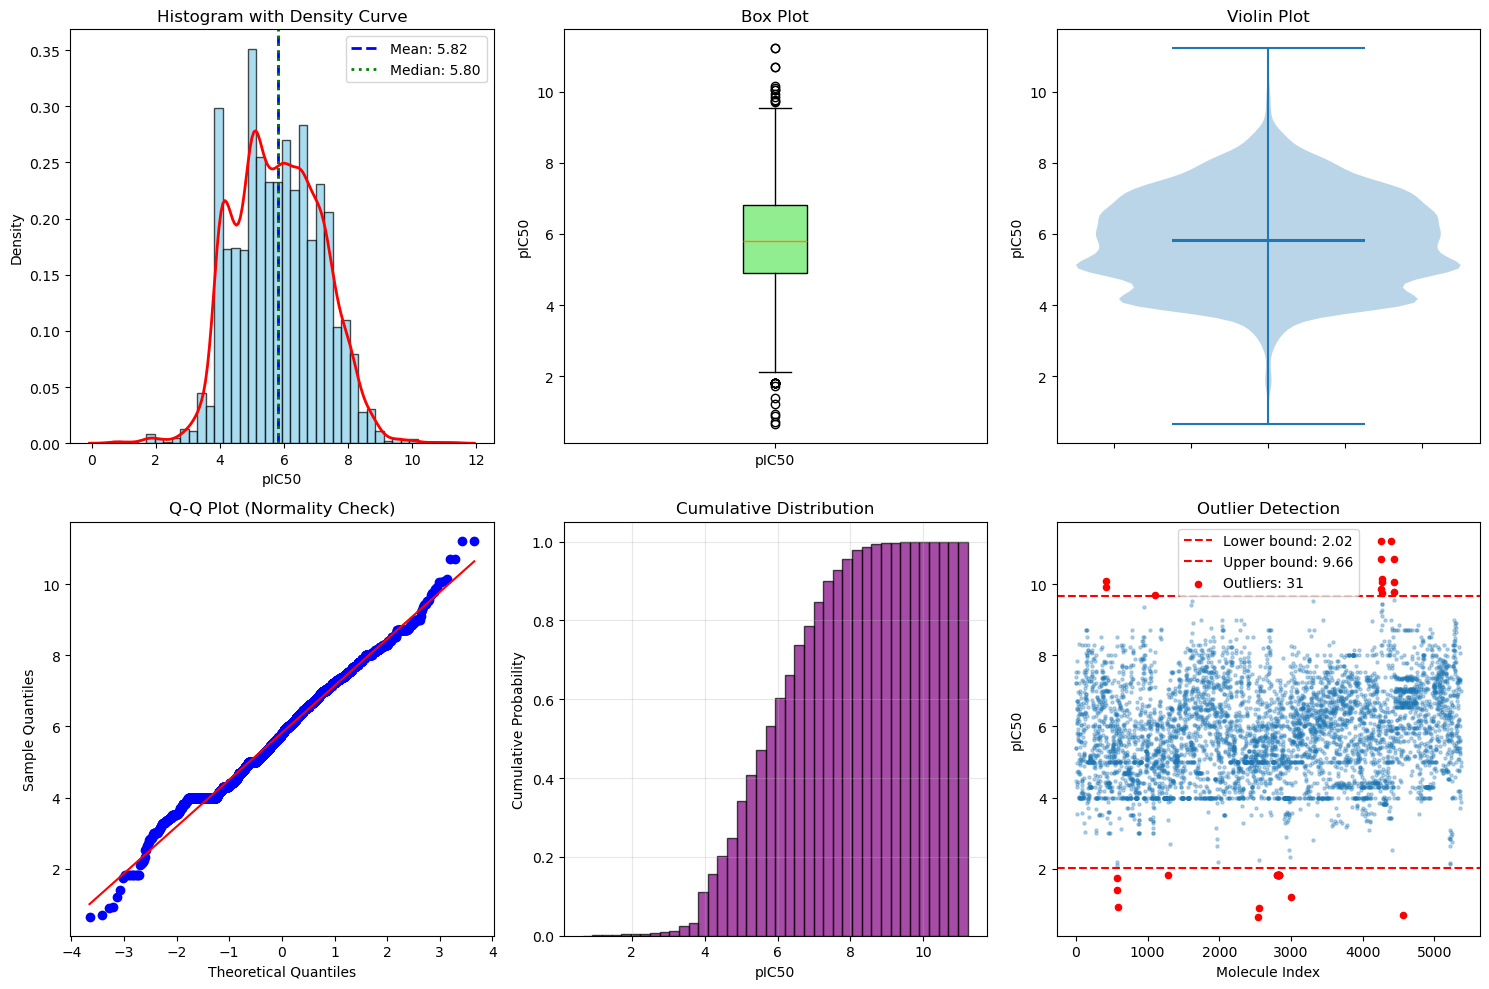


3. OUTLIER ANALYSIS
----------------------------------------
Q1 (25th percentile): 4.890
Q3 (75th percentile): 6.800
IQR: 1.910
Lower bound: 2.025
Upper bound: 9.665
Number of outliers: 31 (0.58%)
Low outliers: 18
High outliers: 13

✓ pIC50 distribution analysis complete


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

# Load data
df = pd.read_csv('cox2_chembl_fingerprints.csv')
print("pIC50 DISTRIBUTION ANALYSIS")
print("=" * 60)

# Extract pIC50 values
pic50 = df['pIC50'].values

# Basic statistics
print("\n1. DESCRIPTIVE STATISTICS")
print("-" * 40)
stats_data = {
    'Statistic': ['Count', 'Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Range', 'Skewness', 'Kurtosis'],
    'Value': [
        f"{len(pic50)}",
        f"{np.mean(pic50):.3f}",
        f"{np.median(pic50):.3f}",
        f"{np.std(pic50):.3f}",
        f"{np.min(pic50):.3f}",
        f"{np.max(pic50):.3f}",
        f"{np.max(pic50) - np.min(pic50):.3f}",
        f"{stats.skew(pic50):.3f}",
        f"{stats.kurtosis(pic50):.3f}"
    ]
}
stats_df = pd.DataFrame(stats_data)
display(stats_df)

# Percentiles
print("\n2. PERCENTILES")
print("-" * 40)
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
percentile_values = np.percentile(pic50, percentiles)
percentile_df = pd.DataFrame({
    'Percentile': [f"{p}th" for p in percentiles],
    'pIC50 Value': [f"{v:.3f}" for v in percentile_values]
})
display(percentile_df)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Histogram with KDE
axes[0, 0].hist(pic50, bins=40, density=True, alpha=0.7, color='skyblue', edgecolor='black')
sns.kdeplot(pic50, ax=axes[0, 0], color='red', linewidth=2)
axes[0, 0].axvline(np.mean(pic50), color='blue', linestyle='--', linewidth=2, label=f"Mean: {np.mean(pic50):.2f}")
axes[0, 0].axvline(np.median(pic50), color='green', linestyle=':', linewidth=2, label=f"Median: {np.median(pic50):.2f}")
axes[0, 0].set_xlabel('pIC50')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Histogram with Density Curve')
axes[0, 0].legend()

# 2. Box plot
axes[0, 1].boxplot(pic50, vert=True, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[0, 1].set_ylabel('pIC50')
axes[0, 1].set_title('Box Plot')
axes[0, 1].set_xticklabels(['pIC50'])

# 3. Violin plot
axes[0, 2].violinplot(pic50, vert=True, showmeans=True, showmedians=True)
axes[0, 2].set_ylabel('pIC50')
axes[0, 2].set_title('Violin Plot')
axes[0, 2].set_xticklabels(['pIC50'])

# 4. Q-Q plot for normality
stats.probplot(pic50, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)')
axes[1, 0].set_xlabel('Theoretical Quantiles')
axes[1, 0].set_ylabel('Sample Quantiles')

# 5. Cumulative distribution
axes[1, 1].hist(pic50, bins=40, cumulative=True, density=True, alpha=0.7, color='purple', edgecolor='black')
axes[1, 1].set_xlabel('pIC50')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].set_title('Cumulative Distribution')
axes[1, 1].grid(True, alpha=0.3)

# 6. Outlier detection (IQR method)
Q1 = np.percentile(pic50, 25)
Q3 = np.percentile(pic50, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = pic50[(pic50 < lower_bound) | (pic50 > upper_bound)]

axes[1, 2].scatter(range(len(pic50)), pic50, alpha=0.3, s=5)
axes[1, 2].axhline(y=lower_bound, color='red', linestyle='--', label=f'Lower bound: {lower_bound:.2f}')
axes[1, 2].axhline(y=upper_bound, color='red', linestyle='--', label=f'Upper bound: {upper_bound:.2f}')
axes[1, 2].scatter(np.where((pic50 < lower_bound) | (pic50 > upper_bound))[0], 
                   outliers, color='red', s=20, label=f'Outliers: {len(outliers)}')
axes[1, 2].set_xlabel('Molecule Index')
axes[1, 2].set_ylabel('pIC50')
axes[1, 2].set_title('Outlier Detection')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

# Outlier summary
print("\n3. OUTLIER ANALYSIS")
print("-" * 40)
print(f"Q1 (25th percentile): {Q1:.3f}")
print(f"Q3 (75th percentile): {Q3:.3f}")
print(f"IQR: {IQR:.3f}")
print(f"Lower bound: {lower_bound:.3f}")
print(f"Upper bound: {upper_bound:.3f}")
print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(pic50)*100:.2f}%)")
print(f"Low outliers: {len(outliers[outliers < lower_bound])}")
print(f"High outliers: {len(outliers[outliers > upper_bound])}")

# Shapiro-Wilk test for normality
from scipy.stats import shapiro
if len(pic50) <= 5000:  # Shapiro test limited to 5000 samples
    shapiro_stat, shapiro_p = shapiro(np.random.choice(pic50, 5000, replace=False))
    print(f"\nShapiro-Wilk normality test p-value: {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print("Data appears normally distributed (p > 0.05)")
    else:
        print("Data does not appear normally distributed (p < 0.05)")

print("\n✓ pIC50 distribution analysis complete")

"The pIC50 values are roughly normally distributed with slight negative skew. The mean is 5.82 and median is 5.80, very close. Only 0.58% of molecules are outliers on the high end (extremely potent compounds). The Q-Q plot confirms approximate normality, which is good for regression modeling."